In [164]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [165]:
df=pd.read_csv('factory_sensor_data.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TimeStamp      1000 non-null   int64  
 1   Temperature_C  970 non-null    float64
 2   Humidity_%     980 non-null    float64
 3   Vibration_mms  985 non-null    float64
 4   Power_kW       955 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


In [166]:
df.columns

Index(['TimeStamp', 'Temperature_C', 'Humidity_%', 'Vibration_mms',
       'Power_kW'],
      dtype='object')

array([[<Axes: title={'center': 'TimeStamp'}>,
        <Axes: title={'center': 'Temperature_C'}>],
       [<Axes: title={'center': 'Humidity_%'}>,
        <Axes: title={'center': 'Vibration_mms'}>],
       [<Axes: title={'center': 'Power_kW'}>, <Axes: >]], dtype=object)

<Figure size 500x500 with 0 Axes>

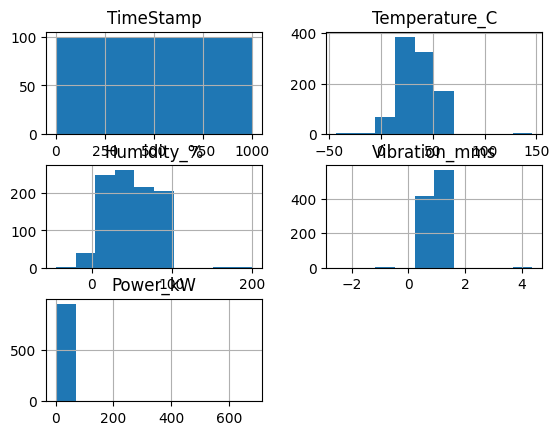

In [167]:
#checking for outliers in each feature
plt.figure(figsize=(5,5))
df.hist()

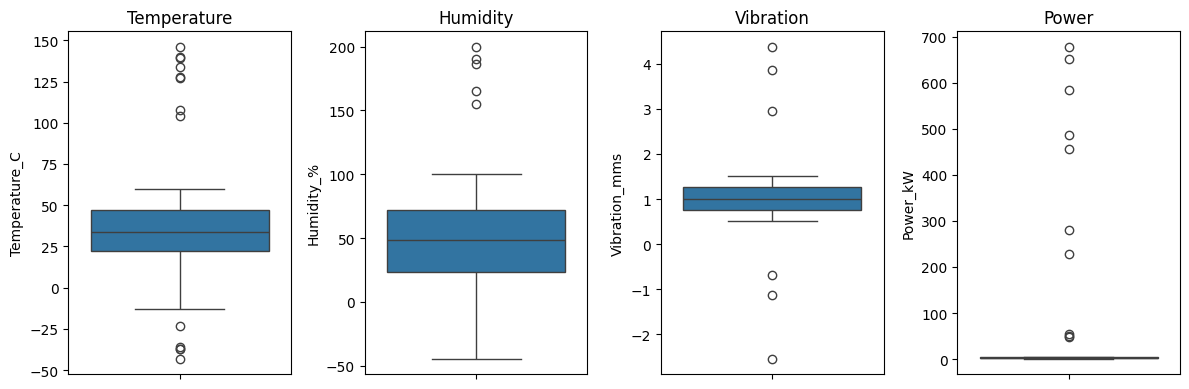

In [168]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
sns.boxplot(y=df["Temperature_C"])
plt.title("Temperature")

plt.subplot(1,4,2)
sns.boxplot(y=df["Humidity_%"])
plt.title("Humidity")

plt.subplot(1,4,3)
sns.boxplot(y=df["Vibration_mms"])
plt.title("Vibration")

plt.subplot(1,4,4)
sns.boxplot(y=df["Power_kW"])
plt.title("Power")

plt.tight_layout()
plt.show()

In [169]:
#removing outliers using IQR method
Q1=df.quantile(0.25)

Q3=df.quantile(0.75)
IQR=Q3-Q1
df=df[
    (df <= (Q3 + 1.5 * IQR)) &
    (df >= (Q1 - 1.5 * IQR))
]



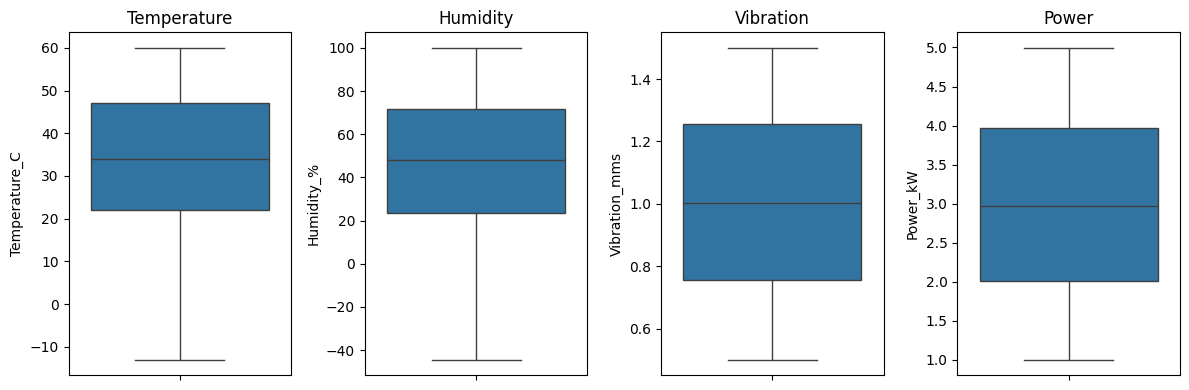

In [170]:
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
sns.boxplot(y=df["Temperature_C"])
plt.title("Temperature")

plt.subplot(1,4,2)
sns.boxplot(y=df["Humidity_%"])
plt.title("Humidity")

plt.subplot(1,4,3)
sns.boxplot(y=df["Vibration_mms"])
plt.title("Vibration")

plt.subplot(1,4,4)
sns.boxplot(y=df["Power_kW"])
plt.title("Power")

plt.tight_layout()
plt.show()

0.8
0.7999999999999998
0.8000000000000003
0.8000000000000007
0.8000000000000007
0.8000000000000007
0.8000000000000007
0.8000000000000007
-13.0 60.0


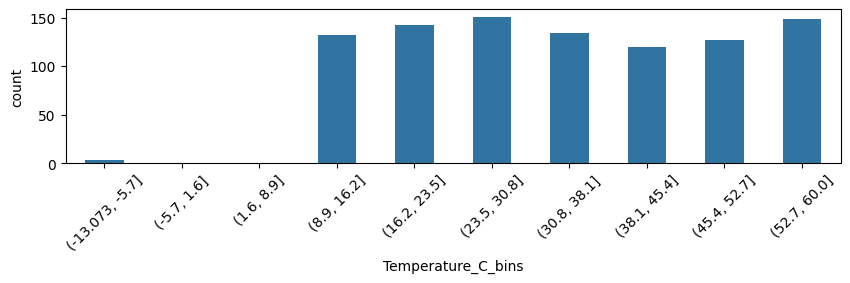

In [171]:
plt.figure(figsize=(10,2))

df["Temperature_C_bins"]=pd.cut(df["Temperature_C"],bins=10)
ax=sns.countplot(x=df["Temperature_C_bins"],data=df)
for bar in ax.patches:
    current_width = bar.get_width()
    print(current_width)
    new_width = 0.5
    bar.set_width(new_width)
    
    # Recenter bars
    bar.set_x(
        bar.get_x() + 
        (current_width - new_width)/2
    )
plt.xticks(rotation=45)
print(df["Temperature_C"].min(),df["Temperature_C"].max())

In [172]:
print(float(df["Temperature_C"].mean()),
float(df["Temperature_C"].std()))

34.28526645768025 14.927338734398651


In [173]:
original_data=df.describe()
print(original_data)

         TimeStamp  Temperature_C  Humidity_%  Vibration_mms    Power_kW
count  1000.000000     957.000000  975.000000     979.000000  945.000000
mean    499.500000      34.285266   48.368834       1.003461    2.983685
std     288.819436      14.927339   28.906928       0.289461    1.150760
min       0.000000     -13.000000  -44.408802       0.501012    1.002588
25%     249.750000      22.000000   23.561382       0.757573    2.002389
50%     499.500000      34.000000   47.967573       1.002872    2.968740
75%     749.250000      47.000000   71.688662       1.254589    3.972348
max     999.000000      60.000000   99.968414       1.499977    4.994207


In [174]:
df.isnull().sum()

TimeStamp              0
Temperature_C         43
Humidity_%            25
Vibration_mms         21
Power_kW              55
Temperature_C_bins    43
dtype: int64

In [175]:
#Humidity data has 25 null values
#Vibration data has 21 null values
#Power data has 55 null values
#temperature has 43 null values

#filling humidity data with mean
df["Humidity_%"]=df["Humidity_%"].fillna(df["Humidity_%"].mean())
df["Humidity_%"].describe()  #did not affect the mean and std of humidity column much 


count    1000.000000
mean       48.368834
std        28.542938
min       -44.408802
25%        24.101308
50%        48.368834
75%        70.909946
max        99.968414
Name: Humidity_%, dtype: float64

In [176]:
df["Temperature_C"]=df["Temperature_C"].fillna(df["Temperature_C"].mean())

df["Power_kW"]=df["Power_kW"].fillna(df["Power_kW"].mean())
    
df["Vibration_mms"]=df["Vibration_mms"].fillna(df["Vibration_mms"].mean())
new_data=np.abs(df.describe()-original_data)
print(new_data)

       TimeStamp  Temperature_C  Humidity_%  Vibration_mms   Power_kW
count        0.0   4.300000e+01   25.000000      21.000000  55.000000
mean         0.0   7.105427e-15    0.000000       0.000000   0.000000
std          0.0   3.247925e-01    0.363990       0.003059   0.032126
min          0.0   0.000000e+00    0.000000       0.000000   0.000000
25%          0.0   7.500000e-01    0.539926       0.007077   0.043168
50%          0.0   2.852665e-01    0.401262       0.000589   0.014946
75%          0.0   0.000000e+00    0.778715       0.003758   0.052422
max          0.0   0.000000e+00    0.000000       0.000000   0.000000
